# Van der pol Oscilator - Centralized observer

In [1]:
import control as ct
import matplotlib.pyplot as plt
import math
import numpy as np
import cvxpy as cp
from scipy.integrate import solve_ivp

from control_utils.politopic_representation import *

rng = np.random.default_rng()

In [2]:
# constants
mi = 1 # damping coeficient
eps = 1e-9 #
ni = 1 # decay rate

z1_interval = [0, 25] # TODO: fix this hardcoded value
z2_interval = [0, 25] # TODO: fix this hardcoded value

# generate combinations for multi-index
q = 2
sigma = 0

a = np.zeros(shape=(8, 4))
b = np.array([5, 5, 10, 10, 5, 5, 10, 10]).reshape(8, 1)+1
bR = np.array([5, 5, 10, 10, 5, 5, 10, 10]).reshape(8, 1)

for i in range(a.shape[1]):
    ind = i + (i * 1)

    a[ind  , i] = 1
    a[ind+1, i] = -1

_, A_index = permn(np.arange(2), 2)

In [3]:
# # Connections Graph construction
# N = 3
# E_half = np.array([(1, 2), (1, 3), (2, 3)])

# if E_half.max() > N:
#     raise Exception("Error in the connections set")

# E_G = np.concat([E_half, np.flip(E_half, axis=1)], axis=0)
# V_G = np.arange(start=1, stop=N+1)
# A_G = np.zeros((N, N))
# D_G = np.zeros((N, N))
# L_G = np.zeros((N, N))

# for i in range(N):
#     for j in range(N):
#         is_in_array = np.any(np.all(E == [i+1, j+1], axis=1))

#         if is_in_array:
#             A_G[i, j] = 1

# for i in range(N):
#     D_G[i, i] = np.sum(A_G[i,:])

# L_G = D_G- A_G

In [4]:
# A_ik = lambda z, xi, mi: np.array([
#     [0, 1, 0, 0],
#     [0, 1/2*mi*(1 - z[0]), 0, -1/2*mi*(1 - z[1])],
#     [0, 0, 0, 1],
#     [0, -1/2*mi*(1 - z[0]), 0, 1/2*mi*(1 - z[1])]
# ])

A_ik = lambda z, xi, mi: np.array([
    [0, 1, 0, 0],
    [0, 0, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 0, 0]
])

C = np.array([
    [1, 0, 0, 0],
    [0, 0, 1, 0]
])

def phi_z(aj: np.ndarray, a: np.ndarray, b: np.ndarray):
    w = cp.Variable((a.shape[0], 1))

    constrains = []

    constrains += [ w >= 0]
    constrains += [ a.T@w == aj ]

    prob = cp.Problem(cp.Minimize(cp.trace(b.T@w)), constraints=constrains)
    result = prob.solve(solver=cp.MOSEK, verbose=False)

    return result

# alpha = [x1, x3]
z_alpha = lambda alpha: np.array([
    alpha[0]**2,
    alpha[1]**2
])

def W_ind(alpha, ind, n_prods):
    '''
    alpha = [x1, x3]
    ind = multiindex
    n_prods = number of products
    '''
    prod = 1

    # ind ~ [0, 1]

    z = z_alpha(alpha)

    w_0 = [
        (z1_interval[1] - z[0]) /(z1_interval[1] - z1_interval[0]),
        (z2_interval[1] - z[1]) /(z2_interval[1] - z2_interval[0])
    ]

    w_1 = [
        1 - w_0[0],
        1 - w_0[1]
    ]

    w = [
        w_0,
        w_1
    ]

    # n_prods = 2
    # ind = (0, 0)
    for i in range(n_prods):
        # i = 0
        # ind[0] = 0
        # w[0] = w_0
        # w_0[0] = w_0^1
        # i = 1
        # ind[1] = 0
        # w[0] = w_0
        # w_0[1] = w_0^2
        prod *= w[ind[i]][i]

    return prod

In [5]:
A_cell = []
for z1 in z1_interval:
    for z2 in z2_interval:
        A_cell.append(A_ik([z1, z2], [], mi))
len(A_cell)

4

In [6]:
A_cell

[array([[0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 0, 0]]),
 array([[0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 0, 0]]),
 array([[0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 0, 0]]),
 array([[0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 0, 0]])]

In [7]:
# check observability
Cobs = []
rank = []
for A in A_cell:
    Cobs.append(ct.obsv(A, C))

for Co in Cobs:
    rank.append(np.linalg.matrix_rank(Co))

if all(np.array(rank) == A_cell[0].shape[0]):
    print("The quasi-LPV model is observable")
else:
    print("The quasi-LPV model is not observable")

The quasi-LPV model is observable


In [8]:
nx = A_cell[0].shape[0]
p = C.shape[0]

_, permsIndex = permn(np.arange(len(A_cell)), 2)
# permsIndex = permsIndex[permsIndex[:, 1] < q] # a fix in the permutations

constrains = []
L_till_array = []

P = cp.Variable((nx, nx), symmetric=True)

for i in range(2**q):
    L_till_array.append(cp.Variable((nx, p)))

constrains += [P >> eps]
# handles permutations
# first index is in A second index is in L
# constrain (14)
Gamma_sum = 0
for ind in permsIndex:
    M = P@A_cell[ind[0]] - L_till_array[ind[1]]@C + ni*P
    Gamma_sum += M + M.T

constrains += [Gamma_sum << -eps]

# constrain (20)
for j in range(a.shape[0]):
    aj = np.expand_dims(a[j, :], axis=1)
    phi = phi_z(aj, a, bR)
    sj = 1/(b[j] - phi) * aj

    M = cp.bmat([
        [np.eye(1), sj.T],
        [sj       , P],
    ])
    constrains += [ M >> 0] # >= breaks -> i know why but cannot remember right now

prob = cp.Problem(cp.Minimize(cp.trace(P)), constraints=constrains)
prob.solve(solver=cp.MOSEK, verbose=True)

                                     CVXPY                                     
                                     v1.6.0                                    
(CVXPY) Feb 23 02:11:41 PM: Your problem has 48 variables, 232 constraints, and 0 parameters.
(CVXPY) Feb 23 02:11:41 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 23 02:11:41 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 23 02:11:41 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 23 02:11:41 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 23 02:11:41 PM: Compiling problem (target solver=MOSEK).
(

11.656854212956672

In [9]:
is_positive_defined = 'positive definite' if all(np.linalg.eig(P.value).eigenvalues > 0) else 'NOT positive defined'
print(f'P = \n{P.value}')
print(f"The solution is \'{prob.status}\', with eig(P) = {np.linalg.eig(P.value).eigenvalues} \n -> P is {is_positive_defined}")

P = 
[[ 4.12135502e+00 -1.70707209e+00  1.28784801e-10 -5.34201822e-11]
 [-1.70707209e+00  1.70707209e+00 -5.34201822e-11  2.21701831e-11]
 [ 1.28784801e-10 -5.34201822e-11  4.12135502e+00 -1.70707209e+00]
 [-5.34201822e-11  2.21701831e-11 -1.70707209e+00  1.70707209e+00]]
The solution is 'optimal', with eig(P) = [5.00497553 5.00497553 0.82345158 0.82345158] 
 -> P is positive definite


In [10]:
P_inv = np.linalg.inv(P.value)

L_array = []

for i in range(len(L_till_array)):
    # print(L_till_array[i].value)
    L_array.append(P_inv@L_till_array[i].value)
    print(L_array[i])
    

[[6.46451260e+00 2.70959177e-10]
 [8.38151221e+00 9.19658780e-10]
 [1.05048008e-09 6.39975837e+00]
 [1.72920041e-09 8.25811576e+00]]
[[ 5.63028964e-01 -1.24231608e-10]
 [ 4.76416343e-01 -2.32229042e-10]
 [-1.29973596e-10  5.78146803e-01]
 [-2.46474000e-10  5.00645934e-01]]
[[ 5.63028939e-01 -1.24229135e-10]
 [ 4.76418371e-01 -2.32230086e-10]
 [-1.29973133e-10  5.78187267e-01]
 [-2.46473021e-10  5.00968585e-01]]
[[ 5.63132473e-01 -1.24490160e-10]
 [ 4.76487817e-01 -2.31580032e-10]
 [-1.33507419e-10  5.97610541e-01]
 [-2.53616109e-10  5.51104464e-01]]


In [11]:
A_index

array([[0, 0],
       [0, 1],
       [1, 0],
       [1, 1]])

In [12]:
def f_x(x, mi):
    return np.array([
        [x[1]],
        [-x[0] + mi*(1 - x[0]**2)*x[1]],
        [x[3]],
        [-x[2] + mi*(1 - x[2]**2)*x[3]]
    ])

def gd_x(x, cp):
    return np.array([
        [0],
        [-cp*math.tanh(x[3] - x[1])],
        [0],
        [-cp*math.tanh(x[1] - x[3])]
    ])

def h_x(x):
    return C@x

def Q_x(x):
    # return np.array([
    #     [0, 0],
    #     [1/2, 1/2],
    #     [0, 0],
    #     [1/2, 1/2]
    # ])

    return np.array([
        [0, 0],
        [1, 0],
        [0, 0],
        [0, 1]
    ])

def Psi_x(x, mi):
    return np.array([
        [-x[0] + mi*(1 - x[0]**2)*x[1]],
        [-x[2] + mi*(1 - x[2]**2)*x[3]]
    ])

def Y_levants(x, cp):
    return np.array([
        [-x[0] + mi*(1 - x[0]**2)*x[1] - cp*(math.tanh(x[3] - x[1]))],
        [-x[2] + mi*(1 - x[2]**2)*x[3] - cp*(math.tanh(x[1] - x[3]))]
    ])

def Gamma_inv(x):
    # return np.array([-1/2, -1/2]).reshape(1, 2)
    return -1*np.eye(2)

def L_alpha(alpha, ind):
    L = 0

    for i in range(ind.shape[0]):
        L += W_ind(alpha, ind[i], q)*L_array[i]

    return L

def model(t: float, x: np.ndarray[float], mi: float, cp: float, dist_hist: list[list]):
    xdot = np.zeros(shape=x.shape)
    xdot = np.expand_dims(xdot, axis=1)

    # for i in range(0, xdot.shape[0]): # when using distributed

        # missing levants differentiator

    d = gd_x(x[0:4], cp)
    d_hat = (Y_levants(x[0:4], cp) - Psi_x(x[4:], mi))

    dist_hist[0].append(t)
    dist_hist[1].append(d)
    dist_hist[2].append(d_hat)

    xdot[0:4] = f_x(x[0:4], mi) + d
    delta = np.expand_dims(C@x[0:4] - h_x(x[4:]), axis=1)
    
    xdot[4:] = f_x(x[4:], mi) + Q_x(x[4:])@(Y_levants(x[4:], cp) - Psi_x(x[4:], mi)) + L_alpha([x[0], x[2]], A_index)@delta

    return xdot.flatten()

In [13]:
# L_alpha test
L_alpha([5, 0], A_index)

array([[ 5.63028939e-01, -1.24229135e-10],
       [ 4.76418371e-01, -2.32230086e-10],
       [-1.29973133e-10,  5.78187267e-01],
       [-2.46473021e-10,  5.00968585e-01]])

In [14]:
time = 20
sim_time = (0, time)
# x0 = np.array([-2, 2, 2, -2])
x0 = np.array([2, 2, 3, -2, 0, 0, 0, 0])

coupling_factor = 1.0

dist_hist = [[], [], []]

result = solve_ivp(model, sim_time, x0, args=(mi, coupling_factor, dist_hist), method="LSODA")
t = result.t
x = result.y

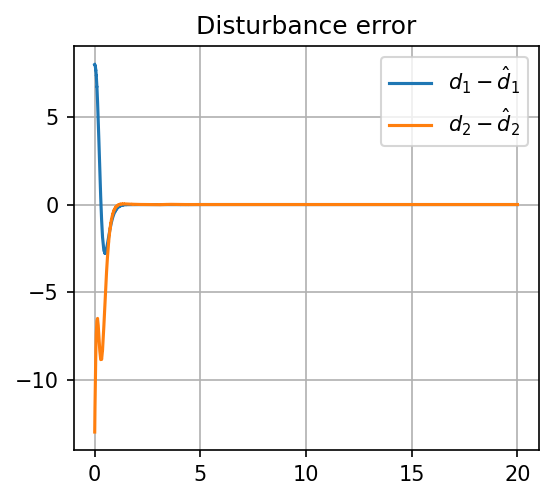

In [15]:
t_dist = np.array(dist_hist[0])
dist = np.array(dist_hist[1])
dist_hat = np.array(dist_hist[2])

plt.figure(figsize=(4, 3.5), dpi=150)
plt.title("Disturbance error")
plt.plot(t_dist, dist[:, 1] - dist_hat[:, 0], label=r'$d_1 - \hat{d}_1$')
plt.plot(t_dist, dist[:, 3] - dist_hat[:, 1], label=r'$d_2 - \hat{d}_2$')
plt.legend()
plt.grid()
plt.show()

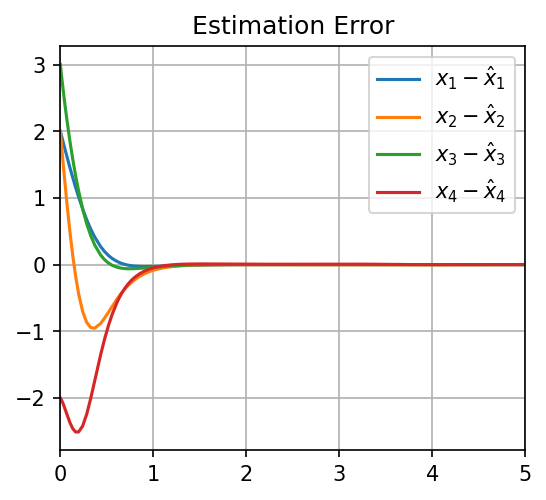

In [16]:
plt.figure(figsize=(4, 3.5), dpi=150)
plt.title("Estimation Error")
plt.plot(t, x[0, :]-x[4, :], label=r'$x_1 - \hat{x}_1$')
plt.plot(t, x[1, :]-x[5, :], label=r'$x_2 - \hat{x}_2$')

plt.plot(t, x[2, :]-x[6, :], label=r'$x_3 - \hat{x}_3$')
plt.plot(t, x[3, :]-x[7, :], label=r'$x_4 - \hat{x}_4$')
plt.xlim([0, 5])
plt.legend()
plt.grid()
plt.show()

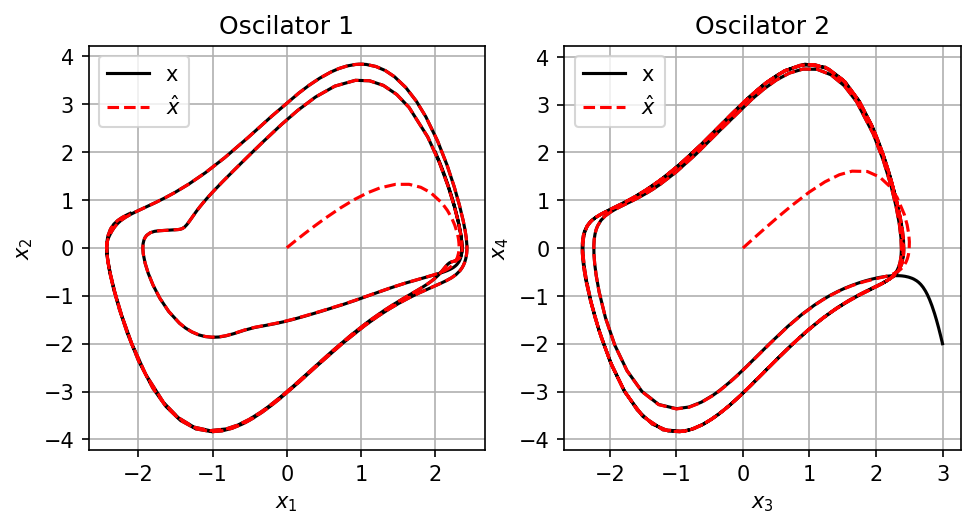

In [17]:
plt.figure(figsize=(7.5, 3.5), dpi=150)
plt.subplot(1, 2, 1)
plt.title("Oscilator 1")
plt.plot(x[0, :], x[1, :], 'k', label='x')
plt.plot(x[4, :], x[5, :], 'r--', label=r'$\hat{x}$')
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.title("Oscilator 2")
plt.plot(x[2, :], x[3, :], 'k', label='x')
plt.plot(x[6, :], x[7, :], 'r--', label=r'$\hat{x}$')
plt.xlabel("$x_3$")
plt.ylabel("$x_4$")

plt.legend()
plt.grid()
plt.show()

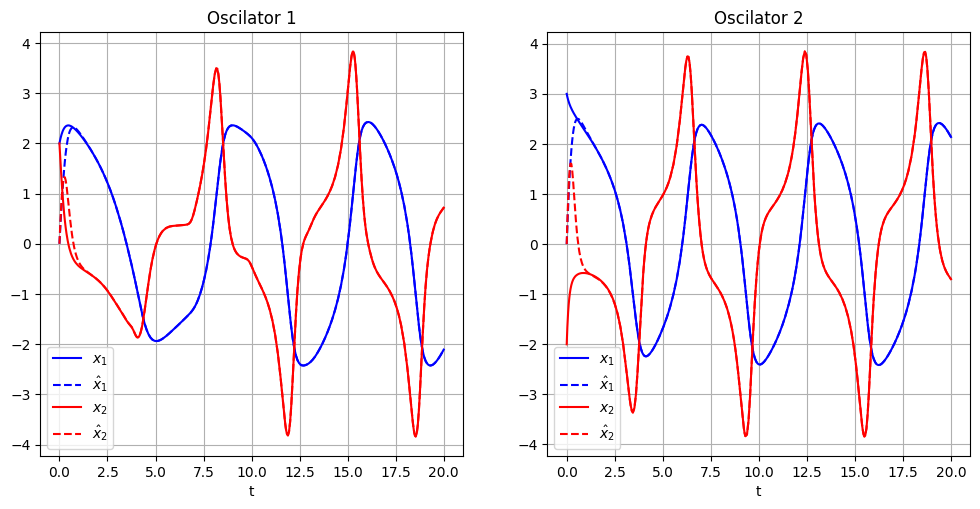

In [18]:
plt.figure(figsize=(12, 5.5), dpi=100)
plt.subplot(1, 2, 1)
plt.title("Oscilator 1")
plt.plot(t, x[0, :], 'b', label=r'$x_1$')
plt.plot(t, x[4, :], 'b--', label=r'$\hat{x}_1$')
plt.plot(t, x[1, :], 'r', label=r'$x_2$')
plt.plot(t, x[5, :], 'r--', label=r'$\hat{x}_2$')
plt.xlabel("t")
plt.legend(loc=3)
plt.grid()

plt.subplot(1, 2, 2)
plt.title("Oscilator 2")
plt.plot(t, x[2, :], 'b', label=r'$x_1$')
plt.plot(t, x[6, :], 'b--', label=r'$\hat{x}_1$')
plt.plot(t, x[3, :], 'r', label=r'$x_2$')
plt.plot(t, x[7, :], 'r--', label=r'$\hat{x}_2$')
plt.xlabel("t")

plt.legend(loc=3)
plt.grid()
plt.show()